# Crowdy â€” Final Decision Flowchart (Single Node)

This notebook regenerates the decision flowchart for the final, single-node version of the privacy-preserving crowd sensing project. The full pipeline runs on an **STM32 Nucleo F446RE**, reads a **MAX9814 microphone**, an **LM393 vibration sensor**, and an **HLK-LD2420 24 GHz radar**, fuses them, and emits the result on **USART2** (the on-board ST-Link virtual COM port).

> **Prerequisite:** PlantUML requires **Java (JDK 8+)** to be installed on your system. Download it from https://adoptium.net or your OS package manager before running this notebook.

In [5]:
!pip install plantuml Pillow

In [6]:
from pathlib import Path
import plantuml
from IPython.display import Image, display

In [7]:
UML_SOURCE = r"""
@startuml
skinparam defaultFontName Arial
skinparam defaultFontSize 11
skinparam ArrowColor #555555
skinparam ActivityBorderColor #555555
skinparam ActivityBackgroundColor #F5F5F5
skinparam ActivityDiamondBackgroundColor #FFF8E1
skinparam ActivityDiamondBorderColor #BA7517
skinparam NoteBackgroundColor #EDE9FE
skinparam NoteBorderColor #7F77DD
skinparam ranksep 18
skinparam nodesep 30

title Crowdy Single-Node Decision Flowchart

start
:Init ADC1+DMA (PA0, PA1)
USART1 RX (radar), USART2 TX (VCP);

repeat
  fork
    :ADC DMA -> mic, vib buffers;
  fork again
    :USART1 ISR -> parse ON / OFF / Range;
  end fork

  if (100 ms tick?) then (yes)
    :Compute mic RMS, vib deviation, radar range avg;
    :Classify each sensor (0..3) and flag disconnects;

    if (All 3 disconnected?) then (yes)
      :Print "All sensors disconnected";
    else (no)
      :Weighted mean of live sensors
-> Empty / Low / Medium / High;
      if (2 disconnected?) then (yes)
        :Append warning;
      else (no)
      endif
      :Format status line;
    endif

    :Send line over USART2 (VCP);
  else (no)
  endif

  if (5 s window?) then (yes)
    :Reset accumulators;
  else (no)
  endif

repeat while (forever)
stop
@enduml
"""

Diagram saved to: D:\Source_Codes\09_Masters\Projects\crowdy\notebooks\final_decision_flowchart2.png


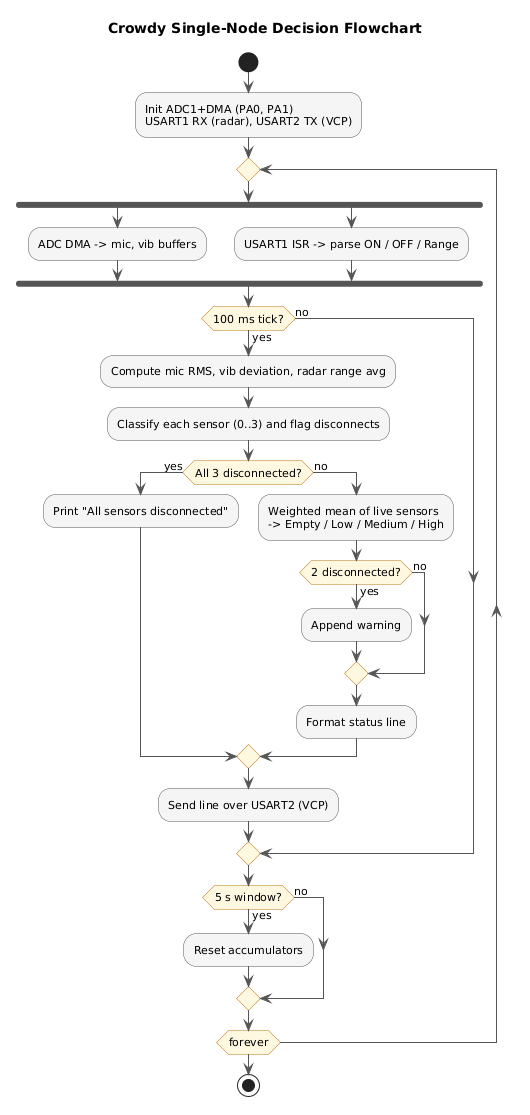

In [8]:
# Render via the PlantUML public server and save as PNG
output_path = Path("final_decision_flowchart2.png")

pl = plantuml.PlantUML(url="http://www.plantuml.com/plantuml/img/")
png_data = pl.processes(UML_SOURCE)

output_path.write_bytes(png_data)
print(f"Diagram saved to: {output_path.resolve()}")

display(Image(filename=str(output_path)))